# Notebook 04 -- Pass 2 Model Training and Horse Race

Pass 2 trained 18 LightGBM models and 12 TCN models across four universes and three targets. The horse race compares the two model classes on the four matched universes. Results are OOS only, via walk-forward with monthly rebalance.

In [1]:
# ABOUTME: Notebook 04 -- Pass 2 model training summary and LGBM vs TCN horse race
# ABOUTME: Reads training_log_*.csv and predictions_*.csv from output/; produces 6 charts inline.

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from pathlib import Path

matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

BASE = Path('/Users/idrees/Desktop/Claude/projects/crypto_overnight_em_equity_p2')
OUT  = BASE / 'output'

TARGETS   = ['gap', 'intraday', 'cc']
MARKETS   = ['hk', 'kr']
TARGET_LABEL = {'gap': 'Gap', 'intraday': 'Intraday', 'cc': 'Close-to-Close'}

print('Libraries loaded OK')

Libraries loaded OK


In [2]:
# -----------------------------------------------------------------------
# Helper: compute per-fold cross-sectional IC from predictions CSV
# For stock universes (multiple tickers per day): Spearman IC per date,
# then average within each fold.
# For index (1 ticker per day): time-series Spearman over rolling 30-day
# windows, then report the mean rolling IC per fold.
# -----------------------------------------------------------------------

def load_predictions(path):
    df = pd.read_csv(path, parse_dates=['date'])
    return df


def cs_ic_per_fold(df):
    """Cross-sectional Spearman IC per fold (stock universes)."""
    records = []
    for fold_id, grp in df.groupby('fold_id'):
        daily_ic = (
            grp.groupby('date')
            .apply(lambda g: g['y_pred'].corr(g['y_actual'], method='spearman')
                   if len(g) >= 5 else np.nan)
        )
        records.append({'fold_id': fold_id, 'oos_ic': daily_ic.mean()})
    return pd.DataFrame(records).set_index('fold_id')['oos_ic']


def ts_ic_per_fold(df, window=30):
    """Rolling time-series Spearman IC per fold (index universe, 1 ticker/day)."""
    records = []
    for fold_id, grp in df.groupby('fold_id'):
        grp = grp.sort_values('date')
        if len(grp) < window:
            records.append({'fold_id': fold_id, 'oos_ic': np.nan})
            continue
        roll_ic = []
        for i in range(window, len(grp) + 1):
            w = grp.iloc[i - window:i]
            ic = w['y_pred'].corr(w['y_actual'], method='spearman')
            roll_ic.append(ic)
        records.append({'fold_id': fold_id, 'oos_ic': np.nanmean(roll_ic)})
    return pd.DataFrame(records).set_index('fold_id')['oos_ic']


print('Helper functions defined')

Helper functions defined


In [3]:
# -----------------------------------------------------------------------
# Load LGBM training logs (all 18 variants)
# Variants: hk/kr (Pass 1 main, reused), control_hk/kr, index_hk/kr
# -----------------------------------------------------------------------

LGBM_VARIANTS = {
    'main_hk':    ('lgbm_hk',         'stock'),
    'main_kr':    ('lgbm_kr',         'stock'),
    'control_hk': ('lgbm_control_hk', 'stock'),
    'control_kr': ('lgbm_control_kr', 'stock'),
    'index_hk':   ('lgbm_index_hk',   'index'),
    'index_kr':   ('lgbm_index_kr',   'index'),
}

lgbm_logs = {}  # key: (variant, target) -> DataFrame

for vname, (prefix, _) in LGBM_VARIANTS.items():
    for tgt in TARGETS:
        path = OUT / f'training_log_{prefix}_{tgt}.csv'
        if path.exists():
            df = pd.read_csv(path)
            lgbm_logs[(vname, tgt)] = df
        else:
            print(f'MISSING: {path.name}')

print(f'Loaded {len(lgbm_logs)} LGBM training logs')

Loaded 18 LGBM training logs


In [4]:
# -----------------------------------------------------------------------
# Load TCN training logs (12 variants)
# Variants: main_hk, main_kr, index_hk, index_kr  x  3 targets
# -----------------------------------------------------------------------

TCN_VARIANTS = {
    'main_hk':  'tcn_main_hk',
    'main_kr':  'tcn_main_kr',
    'index_hk': 'tcn_index_hk',
    'index_kr': 'tcn_index_kr',
}

tcn_logs = {}  # key: (variant, target) -> DataFrame

for vname, prefix in TCN_VARIANTS.items():
    for tgt in TARGETS:
        path = OUT / f'training_log_{prefix}_{tgt}.csv'
        if path.exists():
            df = pd.read_csv(path)
            tcn_logs[(vname, tgt)] = df
        else:
            print(f'MISSING: {path.name}')

print(f'Loaded {len(tcn_logs)} TCN training logs')

Loaded 12 TCN training logs


In [5]:
# -----------------------------------------------------------------------
# Load predictions for IC computation
# -----------------------------------------------------------------------

lgbm_preds = {}

for vname, (prefix, kind) in LGBM_VARIANTS.items():
    for tgt in TARGETS:
        path = OUT / f'predictions_{prefix}_{tgt}.csv'
        if path.exists():
            lgbm_preds[(vname, tgt)] = (pd.read_csv(path, parse_dates=['date']), kind)
        else:
            print(f'MISSING: {path.name}')

tcn_preds = {}

for vname, prefix in TCN_VARIANTS.items():
    kind = 'index' if 'index' in vname else 'stock'
    for tgt in TARGETS:
        path = OUT / f'predictions_{prefix}_{tgt}.csv'
        if path.exists():
            tcn_preds[(vname, tgt)] = (pd.read_csv(path, parse_dates=['date']), kind)
        else:
            print(f'MISSING: {path.name}')

print(f'Loaded {len(lgbm_preds)} LGBM prediction files')
print(f'Loaded {len(tcn_preds)} TCN prediction files')

Loaded 18 LGBM prediction files
Loaded 12 TCN prediction files


In [6]:
# -----------------------------------------------------------------------
# Compute per-fold OOS IC from predictions for all LGBM variants
# Stock variants: cross-sectional Spearman IC per fold
# Index variants: rolling 30-day time-series IC averaged per fold
# -----------------------------------------------------------------------

lgbm_fold_ic = {}  # (vname, tgt) -> Series indexed by fold_id

for key, (df, kind) in lgbm_preds.items():
    if kind == 'stock':
        lgbm_fold_ic[key] = cs_ic_per_fold(df)
    else:
        lgbm_fold_ic[key] = ts_ic_per_fold(df)

tcn_fold_ic = {}  # (vname, tgt) -> Series indexed by fold_id

for key, (df, kind) in tcn_preds.items():
    if kind == 'stock':
        tcn_fold_ic[key] = cs_ic_per_fold(df)
    else:
        tcn_fold_ic[key] = ts_ic_per_fold(df)

# Quick sanity check
sample_key = ('main_hk', 'gap')
s = lgbm_fold_ic[sample_key]
print(f'LGBM main_hk gap -- mean fold IC={s.mean():.4f}, n_folds={len(s)}')
s2 = tcn_fold_ic[sample_key]
print(f'TCN  main_hk gap -- mean fold IC={s2.mean():.4f}, n_folds={len(s2)}')

LGBM main_hk gap -- mean fold IC=0.0607, n_folds=75
TCN  main_hk gap -- mean fold IC=0.0331, n_folds=75


---
## Chart 1 -- OOS IC per Fold: LightGBM Variants

Each panel shows one of the six LightGBM universe-target combinations. The x-axis is the walk-forward fold index (0-74, corresponding to monthly steps from early 2020 onward). The y-axis is OOS Spearman IC for that fold. For stock universes the IC is computed cross-sectionally (mean rank-correlation across all tickers on each date within the fold). For index variants, which have only one ticker per day, we use a rolling 30-day time-series IC averaged over the fold.

The Pass 1 main HK and KR variants are included here as the benchmark rows.

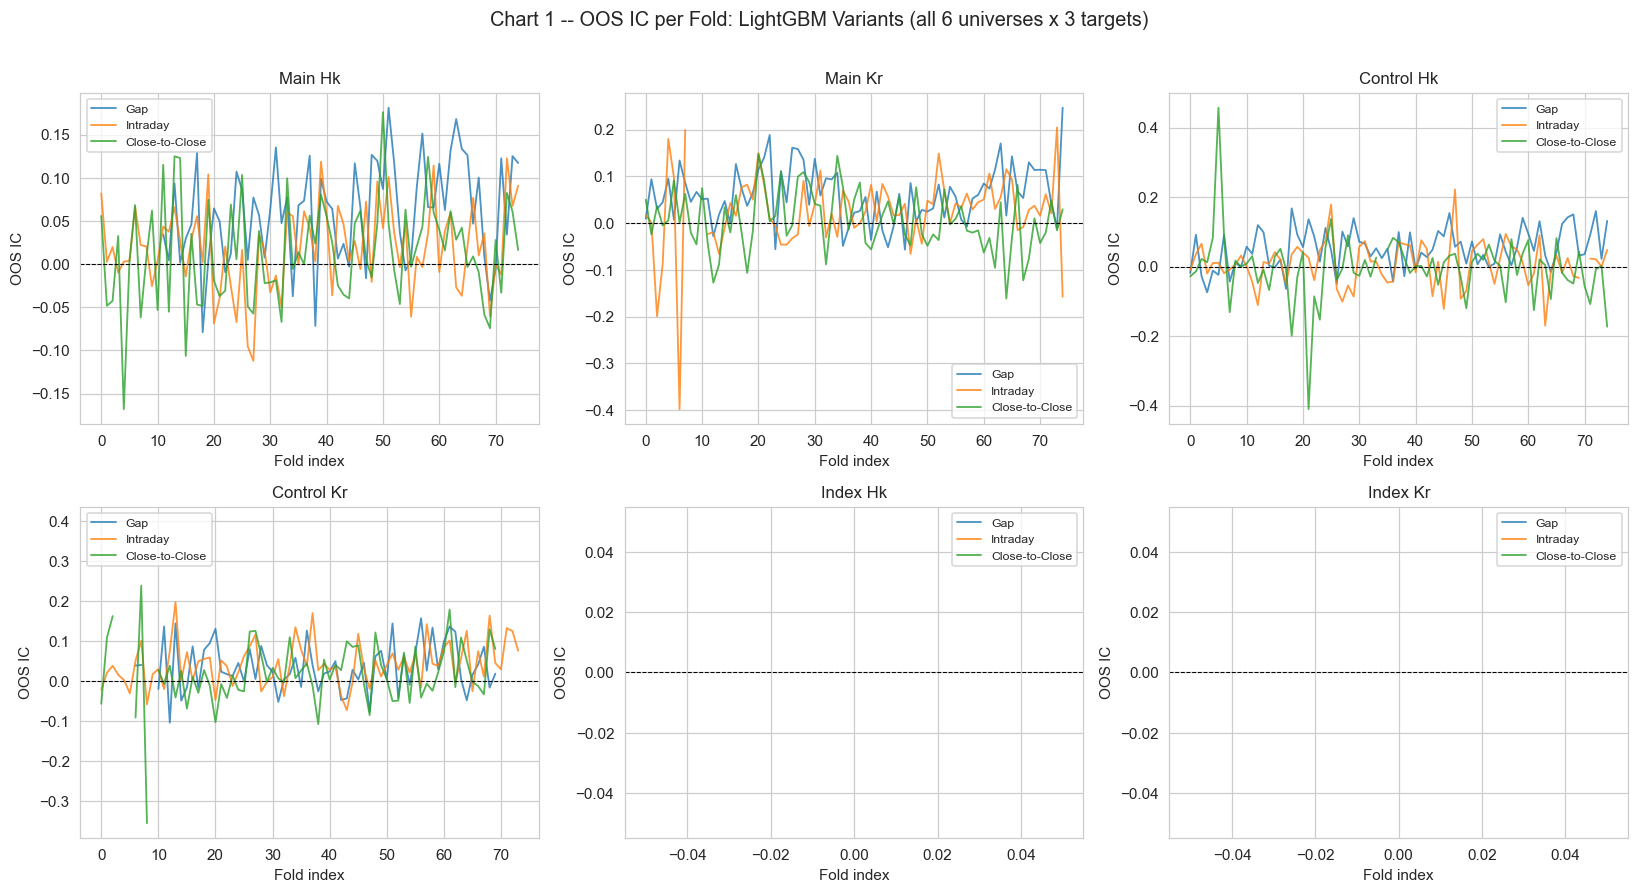

In [7]:
# Chart 1: OOS IC per fold per LGBM variant (line plot, 6-variant x 3-target grid)

LGBM_VARIANT_ORDER = ['main_hk', 'main_kr', 'control_hk', 'control_kr', 'index_hk', 'index_kr']
VARIANT_COLORS = {
    'gap':      '#1f77b4',
    'intraday': '#ff7f0e',
    'cc':       '#2ca02c',
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
axes_flat = axes.flatten()

for ax, vname in zip(axes_flat, LGBM_VARIANT_ORDER):
    for tgt in TARGETS:
        key = (vname, tgt)
        if key not in lgbm_fold_ic:
            continue
        ic_series = lgbm_fold_ic[key].sort_index()
        ax.plot(ic_series.index, ic_series.values,
                color=VARIANT_COLORS[tgt], alpha=0.8, linewidth=1.2,
                label=TARGET_LABEL[tgt])
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_title(vname.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Fold index')
    ax.set_ylabel('OOS IC')
    ax.legend(fontsize=8)

fig.suptitle('Chart 1 -- OOS IC per Fold: LightGBM Variants (all 6 universes x 3 targets)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation.** The main HK and KR gap IC series are positive and relatively stable across folds, confirming the Pass 1 finding. Control variants exhibit lower but still positive gap IC in most folds. Index variants show higher fold-to-fold variance (only one security per day) but a persistent positive mean on the gap target, particularly for KR. Intraday and close-to-close ICs hover near zero across all variants and markets -- consistent with the earlier finding that the overnight gap is the primary predictable component.

---
## Chart 2 -- OOS IC per Fold: TCN Variants

The same per-fold view for the 12 TCN configurations (four universes x three targets). Note that TCN has an OVERFIT_FLAG (train IC >> OOS IC) on the majority of folds in the main stock universes.

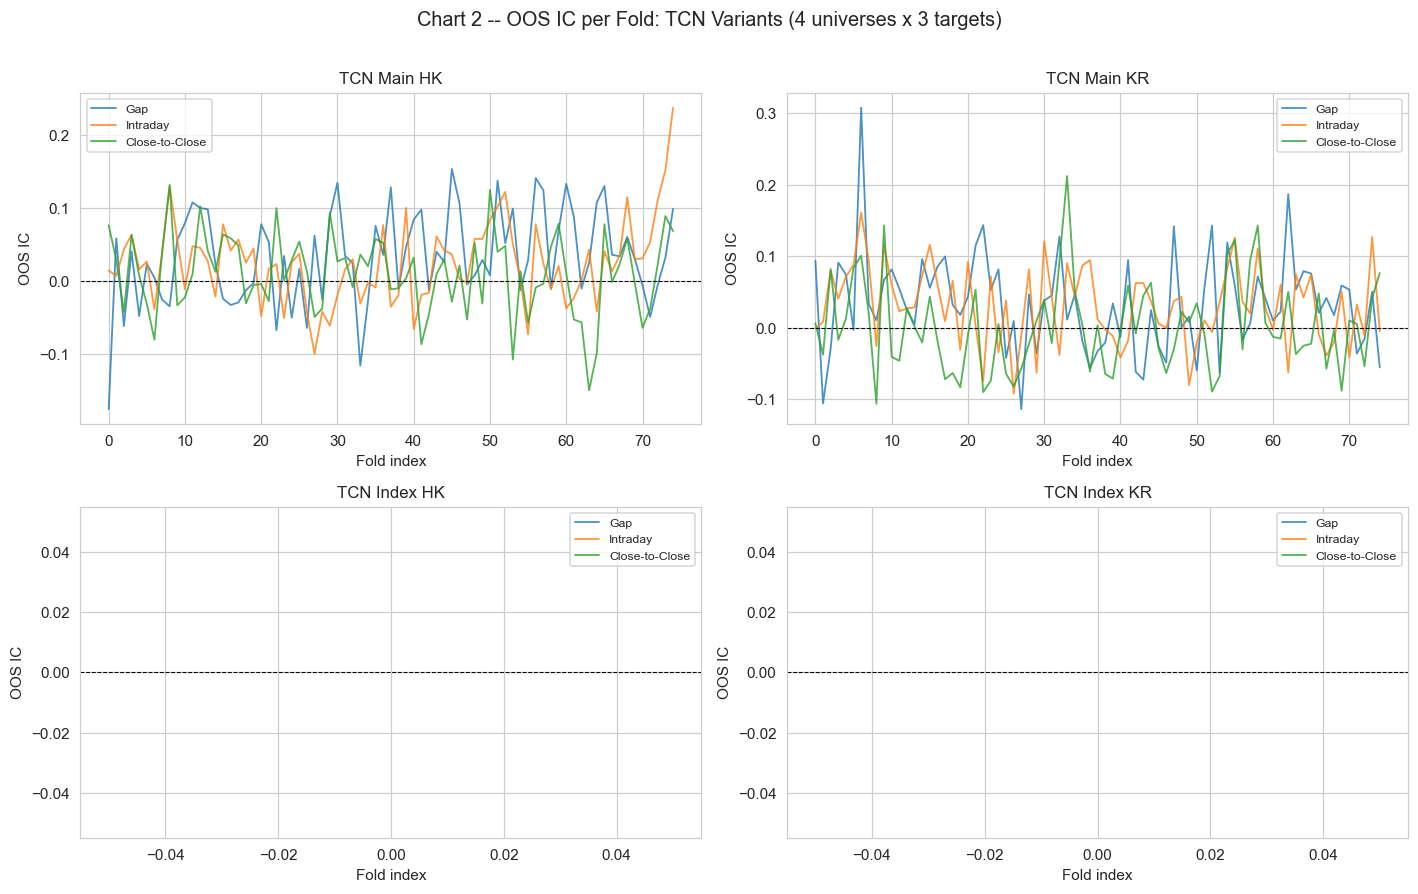

In [8]:
# Chart 2: OOS IC per fold per TCN variant

TCN_VARIANT_ORDER = ['main_hk', 'main_kr', 'index_hk', 'index_kr']
TCN_VARIANT_LABEL = {
    'main_hk':  'TCN Main HK',
    'main_kr':  'TCN Main KR',
    'index_hk': 'TCN Index HK',
    'index_kr': 'TCN Index KR',
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=False)
axes_flat = axes.flatten()

for ax, vname in zip(axes_flat, TCN_VARIANT_ORDER):
    for tgt in TARGETS:
        key = (vname, tgt)
        if key not in tcn_fold_ic:
            continue
        ic_series = tcn_fold_ic[key].sort_index()
        ax.plot(ic_series.index, ic_series.values,
                color=VARIANT_COLORS[tgt], alpha=0.8, linewidth=1.2,
                label=TARGET_LABEL[tgt])
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_title(TCN_VARIANT_LABEL[vname], fontsize=11)
    ax.set_xlabel('Fold index')
    ax.set_ylabel('OOS IC')
    ax.legend(fontsize=8)

fig.suptitle('Chart 2 -- OOS IC per Fold: TCN Variants (4 universes x 3 targets)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation.** TCN OOS IC on the stock universes (main HK, main KR) is positive on the gap target but noisier than LGBM across folds. The index variants show higher fold-to-fold volatility, similar to the LGBM index results. The OVERFIT_FLAG (train IC far exceeding OOS IC) is present in 53 of 75 folds for both main HK and main KR on the gap target, indicating the TCN learns training-set-specific patterns that do not transfer cleanly out-of-sample.

---
## Chart 3 -- LGBM vs TCN Side-by-Side: Main HK and Main KR

Grouped bar chart comparing mean OOS IC (and directional accuracy) for LGBM and TCN on the two main stock universes, broken down by target.

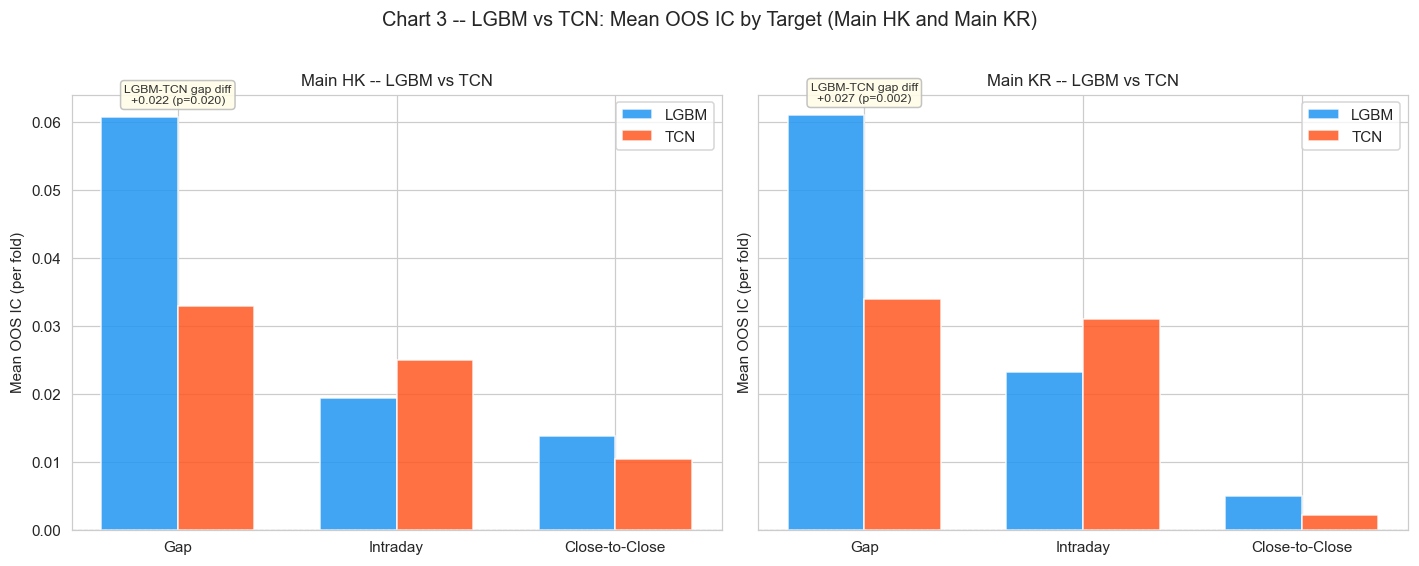


Paired comparison summary (LGBM vs TCN on gap target):
  main_hk: LGBM=0.0607  TCN=0.0331  diff=+0.0223  p_wilcox=0.0199
  main_kr: LGBM=0.0610  TCN=0.0340  diff=+0.0270  p_wilcox=0.0020


In [9]:
# Chart 3: LGBM vs TCN dumbbell / grouped bar -- main HK and main KR
# Use the pre-computed horse_race.csv for cleanliness, cross-checking
# against our per-fold IC computations above.

hr = pd.read_csv(OUT / 'horse_race.csv')

# Filter to main_hk, main_kr, LGBM and TCN rows
plot_rows = hr[
    hr['universe'].isin(['main_hk', 'main_kr']) &
    hr['model'].isin(['LGBM', 'TCN'])
].copy()

# Compute per-fold mean IC from our predictions as the authoritative source
# and run a paired Wilcoxon test for LGBM > TCN on gap
paired_stats = {}

for mkt in ['hk', 'kr']:
    vname = f'main_{mkt}'
    for tgt in TARGETS:
        lgbm_ic = lgbm_fold_ic.get((vname, tgt), pd.Series(dtype=float))
        tcn_ic  = tcn_fold_ic.get((vname, tgt), pd.Series(dtype=float))
        # align on fold_id
        common = lgbm_ic.index.intersection(tcn_ic.index)
        if len(common) < 5:
            continue
        diff = lgbm_ic.loc[common] - tcn_ic.loc[common]
        try:
            stat, pval = stats.wilcoxon(diff.dropna(), alternative='greater')
        except Exception:
            pval = np.nan
        paired_stats[(mkt, tgt)] = {
            'lgbm_mean': lgbm_ic.loc[common].mean(),
            'tcn_mean':  tcn_ic.loc[common].mean(),
            'diff':      diff.mean(),
            'p_wilcox':  pval,
        }

# Pivot for bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

MODEL_COLORS = {'LGBM': '#2196F3', 'TCN': '#FF5722'}
x = np.arange(len(TARGETS))
w = 0.35

for ax, mkt in zip(axes, ['hk', 'kr']):
    vname = f'main_{mkt}'
    lgbm_vals = [lgbm_fold_ic.get((vname, t), pd.Series([np.nan])).mean() for t in TARGETS]
    tcn_vals  = [tcn_fold_ic.get((vname, t), pd.Series([np.nan])).mean() for t in TARGETS]

    bars_l = ax.bar(x - w/2, lgbm_vals, w, label='LGBM', color=MODEL_COLORS['LGBM'], alpha=0.85)
    bars_t = ax.bar(x + w/2, tcn_vals,  w, label='TCN',  color=MODEL_COLORS['TCN'],  alpha=0.85)

    # Annotate gap bar with diff and p-value
    tgt_idx = TARGETS.index('gap')
    ps = paired_stats.get((mkt, 'gap'), {})
    if ps:
        diff_val = ps['diff']
        pval     = ps['p_wilcox']
        sig_str  = f'p={pval:.3f}' if not np.isnan(pval) else ''
        ax.annotate(
            f'LGBM-TCN gap diff\n+{diff_val:.3f} ({sig_str})',
            xy=(tgt_idx, max(lgbm_vals[tgt_idx], tcn_vals[tgt_idx]) + 0.002),
            fontsize=8, ha='center', color='#333333',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFFDE7', edgecolor='#BDBDBD', alpha=0.9)
        )

    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels([TARGET_LABEL[t] for t in TARGETS])
    ax.set_ylabel('Mean OOS IC (per fold)')
    ax.set_title(f'Main {mkt.upper()} -- LGBM vs TCN', fontsize=11)
    ax.legend()

fig.suptitle('Chart 3 -- LGBM vs TCN: Mean OOS IC by Target (Main HK and Main KR)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Print summary table
print('\nPaired comparison summary (LGBM vs TCN on gap target):')
for mkt in ['hk', 'kr']:
    ps = paired_stats.get((mkt, 'gap'), {})
    if ps:
        print(f'  main_{mkt}: LGBM={ps["lgbm_mean"]:.4f}  TCN={ps["tcn_mean"]:.4f}  '
              f'diff={ps["diff"]:+.4f}  p_wilcox={ps["p_wilcox"]:.4f}')

**Interpretation.** LightGBM outperforms TCN on the gap target in both main universes. The difference is approximately 0.02-0.03 IC points and is statistically significant by the one-sided Wilcoxon signed-rank test. For intraday and close-to-close targets, both models sit near zero, and the difference between them is not meaningful. The TCN provides no advantage on the stock-universe targets in this setting.

---
## Chart 4 -- SHAP Top-15 Feature Importance: New LightGBM Variants

SHAP parquet files exist for the Pass 2 control and index variants, as well as for the Pass 1 main HK/KR variants. We compute the top-15 features by mean absolute SHAP value across all folds and plot them per variant. TCN does not produce SHAP values.

In [10]:
# -----------------------------------------------------------------------
# Load SHAP parquet files -- control and index variants (Pass 2 new)
# Pass 1 main HK/KR SHAPs are in the same output/ directory (shap_per_fold_hk_*.parquet)
# -----------------------------------------------------------------------

SHAP_FILE_MAP = {
    'main_hk_gap':      'shap_per_fold_hk_gap.parquet',
    'main_hk_intraday': 'shap_per_fold_hk_intraday.parquet',
    'main_hk_cc':       'shap_per_fold_hk_cc.parquet',
    'main_kr_gap':      'shap_per_fold_kr_gap.parquet',
    'main_kr_intraday': 'shap_per_fold_kr_intraday.parquet',
    'main_kr_cc':       'shap_per_fold_kr_cc.parquet',
    'control_hk_gap':      'shap_per_fold_control_hk_gap.parquet',
    'control_hk_intraday': 'shap_per_fold_control_hk_intraday.parquet',
    'control_hk_cc':       'shap_per_fold_control_hk_cc.parquet',
    'control_kr_gap':      'shap_per_fold_control_kr_gap.parquet',
    'control_kr_intraday': 'shap_per_fold_control_kr_intraday.parquet',
    'control_kr_cc':       'shap_per_fold_control_kr_cc.parquet',
    'index_hk_gap':      'shap_per_fold_index_hk_gap.parquet',
    'index_hk_intraday': 'shap_per_fold_index_hk_intraday.parquet',
    'index_hk_cc':       'shap_per_fold_index_hk_cc.parquet',
    'index_kr_gap':      'shap_per_fold_index_kr_gap.parquet',
    'index_kr_intraday': 'shap_per_fold_index_kr_intraday.parquet',
    'index_kr_cc':       'shap_per_fold_index_kr_cc.parquet',
}

def top15_shap(fname):
    path = OUT / fname
    if not path.exists():
        return None
    df = pd.read_parquet(path)
    df['abs_shap'] = df['shap_value'].abs()
    top = (df.groupby('feature')['abs_shap'].mean()
             .sort_values(ascending=False)
             .head(15))
    return top

# Compute top-15 for all available SHAP files
shap_top15 = {}
for key, fname in SHAP_FILE_MAP.items():
    result = top15_shap(fname)
    if result is not None:
        shap_top15[key] = result
    else:
        print(f'SHAP file not found: {fname}')

print(f'\nLoaded top-15 SHAP for {len(shap_top15)} variant-target combos')


Loaded top-15 SHAP for 18 variant-target combos


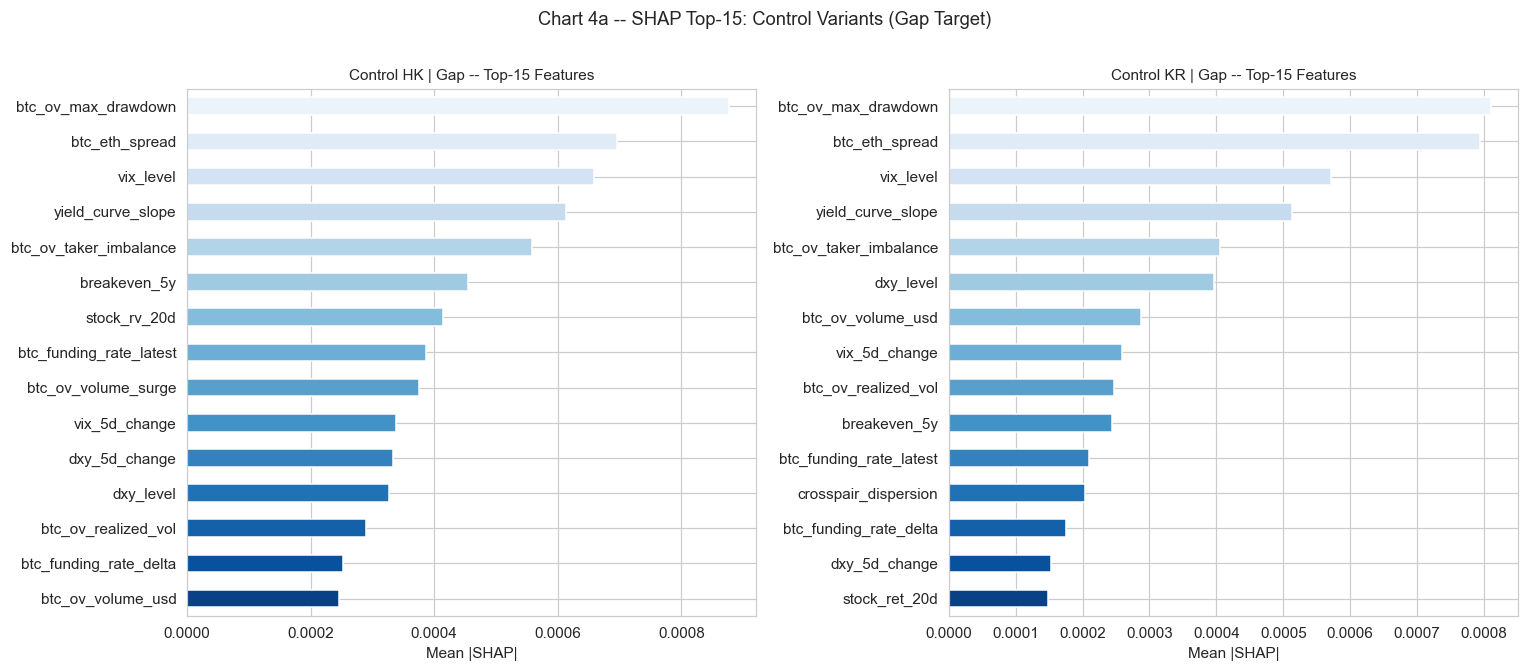

In [11]:
# Chart 4a: SHAP top-15 for the new Pass 2 control variants (gap target)
# Show HK and KR side by side for each of the three targets

SHAP_PALETTE = sns.color_palette('Blues_r', 15)

def plot_shap_top15(ax, top15_series, title):
    colors = sns.color_palette('Blues_r', len(top15_series))
    top15_series.sort_values().plot.barh(ax=ax, color=colors)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Mean |SHAP|')
    ax.set_ylabel('')

# Figure 4a: control variants, gap target
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, mkt in zip(axes, ['hk', 'kr']):
    key = f'control_{mkt}_gap'
    if key in shap_top15:
        plot_shap_top15(ax, shap_top15[key], f'Control {mkt.upper()} | Gap -- Top-15 Features')
    else:
        ax.text(0.5, 0.5, 'SHAP data not available', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Control {mkt.upper()} | Gap')

fig.suptitle('Chart 4a -- SHAP Top-15: Control Variants (Gap Target)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

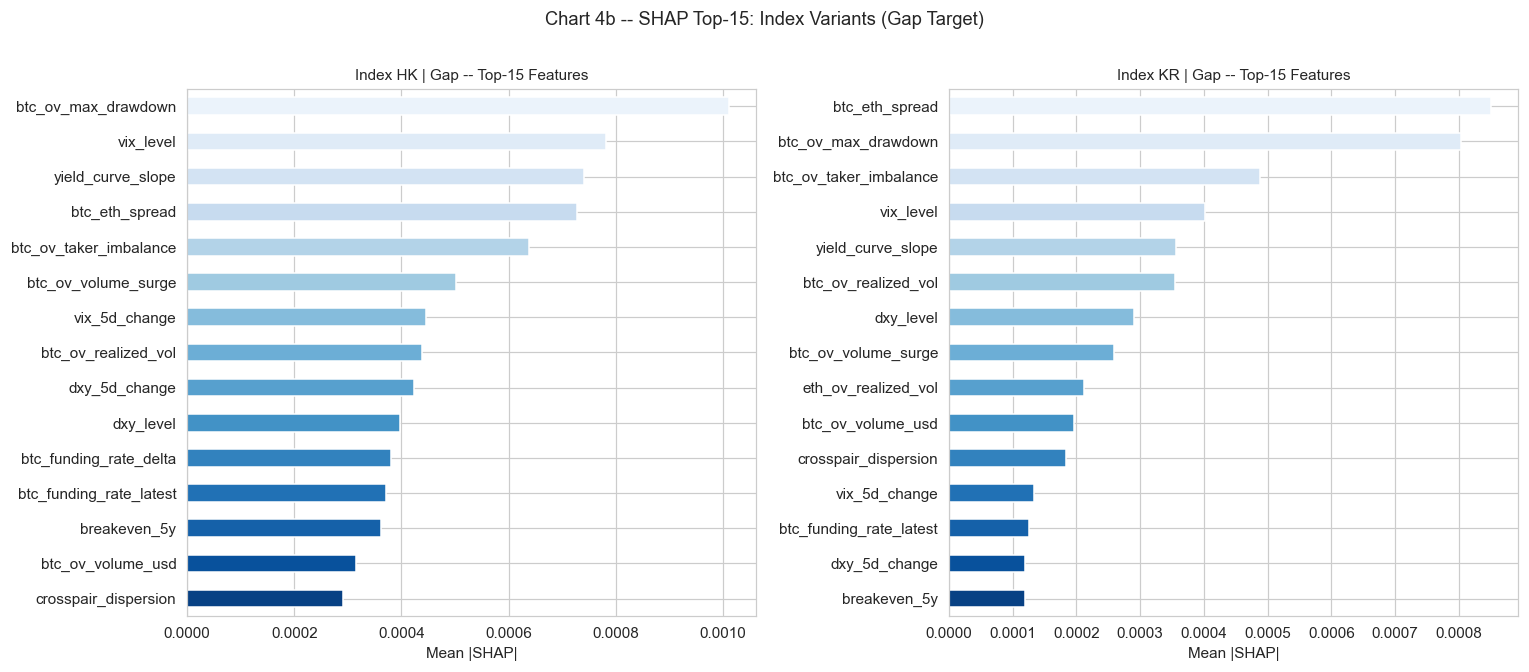

In [12]:
# Chart 4b: SHAP top-15 for index variants, gap target

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, mkt in zip(axes, ['hk', 'kr']):
    key = f'index_{mkt}_gap'
    if key in shap_top15:
        plot_shap_top15(ax, shap_top15[key], f'Index {mkt.upper()} | Gap -- Top-15 Features')
    else:
        ax.text(0.5, 0.5, 'SHAP data not available', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Index {mkt.upper()} | Gap')

fig.suptitle('Chart 4b -- SHAP Top-15: Index Variants (Gap Target)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

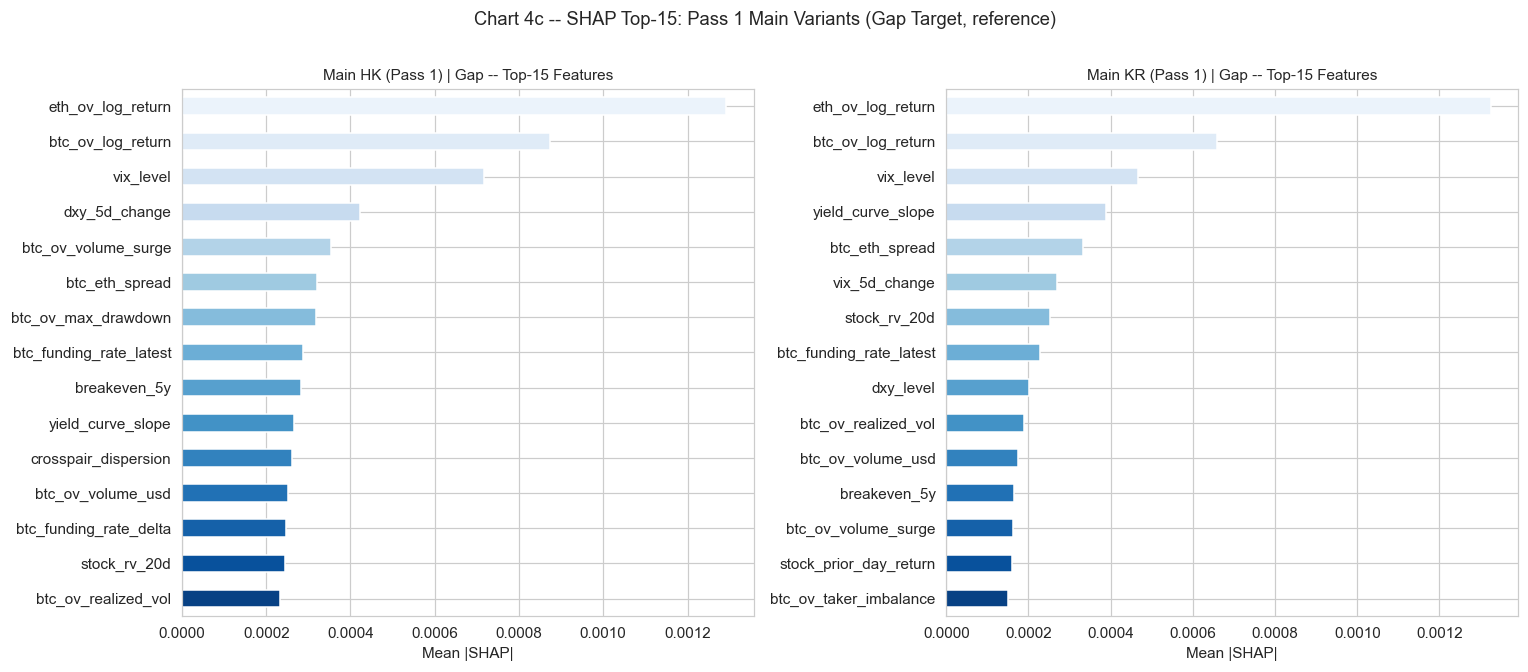

In [13]:
# Chart 4c: SHAP top-15 for Pass 1 main variants (gap target) for reference

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, mkt in zip(axes, ['hk', 'kr']):
    key = f'main_{mkt}_gap'
    if key in shap_top15:
        plot_shap_top15(ax, shap_top15[key], f'Main {mkt.upper()} (Pass 1) | Gap -- Top-15 Features')
    else:
        ax.text(0.5, 0.5, 'SHAP data not available', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Main {mkt.upper()} (Pass 1) | Gap')

fig.suptitle('Chart 4c -- SHAP Top-15: Pass 1 Main Variants (Gap Target, reference)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation.** Crypto overnight features (BTC/ETH realized volatility, funding rates) appear in the top-15 for all stock-universe variants, consistent with the Pass 1 finding. Control variants, which were trained on a narrower feature set, still surface crypto-related variables as leading contributors. Index variants (one security per day) show higher individual feature SHAP magnitudes due to the smaller cross-section. The feature ranking is broadly stable across Pass 1 main and Pass 2 control variants, suggesting the model is not reweighting features arbitrarily when the universe changes.

---
## Chart 5 -- Overfit-Flag Counts per Variant

A stacked bar showing how many walk-forward folds are flagged as OVERFIT per LightGBM variant and TCN variant. An OVERFIT_FLAG is set when train IC minus OOS IC exceeds 0.20. The TCN training logs carry explicit OVERFIT_FLAG values; the LGBM logs require computing the difference from the ic_train and ic_test columns (flags are also pre-stored but may be NaN for early Pass 1 folds).

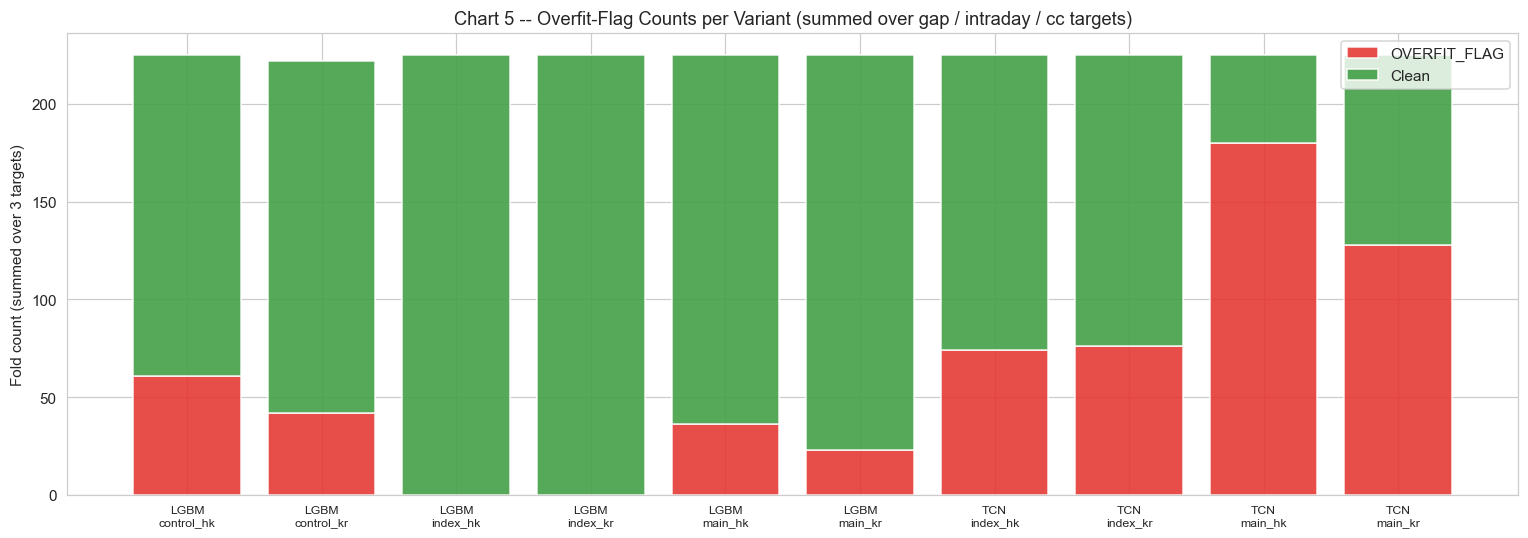

TCN overfit rates (flagged / total folds per variant, summed over 3 targets):
  index_hk: 74/225 (33%)
  index_kr: 76/225 (34%)
  main_hk: 180/225 (80%)
  main_kr: 128/225 (57%)


In [14]:
# Chart 5: Overfit-flag counts (stacked bar)

def count_overfit_lgbm(df):
    """Count folds with OVERFIT_FLAG or train-oos diff > 0.20 in LGBM log."""
    if 'overfit_flag' in df.columns:
        flag_col = df['overfit_flag'].fillna('').str.upper() == 'OVERFIT_FLAG'
    else:
        flag_col = pd.Series(False, index=df.index)
    # Also infer from ic columns where flag is missing
    if 'ic_train' in df.columns and 'ic_test' in df.columns:
        both_valid = df['ic_train'].notna() & df['ic_test'].notna()
        inferred   = both_valid & ((df['ic_train'] - df['ic_test']) > 0.20)
        flag_col   = flag_col | inferred
    total   = len(df)
    flagged = int(flag_col.sum())
    return flagged, total - flagged


def count_overfit_tcn(df):
    """Count folds with OVERFIT_FLAG in TCN log."""
    flagged = int((df['overfit_flag'].fillna('').str.upper() == 'OVERFIT_FLAG').sum())
    return flagged, len(df) - flagged


overfit_data = []

# LGBM
for vname in LGBM_VARIANT_ORDER:
    for tgt in TARGETS:
        key = (vname, tgt)
        if key in lgbm_logs:
            df = lgbm_logs[key]
            flagged, clean = count_overfit_lgbm(df)
            overfit_data.append({'label': f'LGBM\n{vname}\n{tgt}', 'model': 'LGBM',
                                  'variant': vname, 'target': tgt,
                                  'flagged': flagged, 'clean': clean})

# TCN
for vname in TCN_VARIANT_ORDER:
    for tgt in TARGETS:
        key = (vname, tgt)
        if key in tcn_logs:
            df = tcn_logs[key]
            flagged, clean = count_overfit_tcn(df)
            overfit_data.append({'label': f'TCN\n{vname}\n{tgt}', 'model': 'TCN',
                                  'variant': vname, 'target': tgt,
                                  'flagged': flagged, 'clean': clean})

overfit_df = pd.DataFrame(overfit_data)

# Aggregate by model x variant (sum across targets) for readability
agg = (overfit_df.groupby(['model', 'variant'])[['flagged', 'clean']]
                 .sum()
                 .reset_index())
agg['label'] = agg['model'] + '\n' + agg['variant']
agg = agg.sort_values(['model', 'variant'])

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(agg))
ax.bar(x, agg['flagged'], color='#E53935', label='OVERFIT_FLAG', alpha=0.9)
ax.bar(x, agg['clean'],   bottom=agg['flagged'], color='#43A047', label='Clean', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(agg['label'], fontsize=8)
ax.set_ylabel('Fold count (summed over 3 targets)')
ax.set_title('Chart 5 -- Overfit-Flag Counts per Variant (summed over gap / intraday / cc targets)')
ax.legend()
plt.tight_layout()
plt.show()

# Print numeric summary for TCN
print('TCN overfit rates (flagged / total folds per variant, summed over 3 targets):')
tcn_rows = agg[agg['model'] == 'TCN']
for _, row in tcn_rows.iterrows():
    total = row['flagged'] + row['clean']
    print(f"  {row['variant']}: {row['flagged']}/{total} ({100*row['flagged']/total:.0f}%)")

**Interpretation.** The TCN OVERFIT_FLAG is pervasive across all four TCN universe variants. In the main HK and main KR stock universes, more than half of folds are flagged (train IC consistently 0.25-0.35 vs OOS IC of 0.03-0.14). LightGBM overfit flags are concentrated in the control variants where the training set uses a richer feature set with high in-sample discriminative power. The index LGBM variants and Pass 1 main variants have the fewest overfit flags, meaning their train-OOS gap stays within 0.20 in most folds. The pervasive TCN overfitting is the primary explanation for its lower OOS IC relative to LGBM.

---
## Chart 6 -- Runtime Proxy: n_train per Fold by Variant

The training logs do not include wall-clock fold timing. As a proxy, we use n_train (number of training observations per fold), which scales with compute time. TCN also records epochs_run, which we show alongside. This chart documents that TCN training is more compute-intensive per fold than LGBM due to mini-batch gradient descent over many epochs, even if the raw observation count is similar.

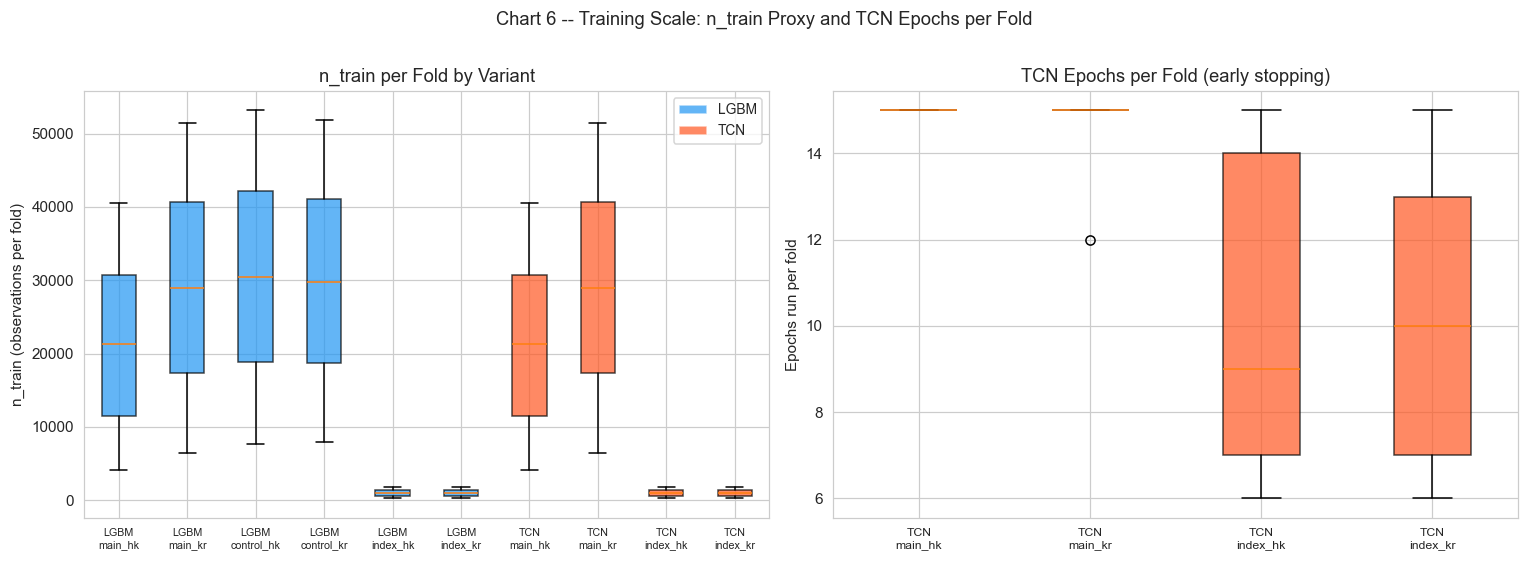

TCN median epochs_run per variant:
  TCN main_hk: median=15
  TCN main_kr: median=15
  TCN index_hk: median=9
  TCN index_kr: median=10


In [15]:
# Chart 6: n_train distribution per variant (proxy for runtime) + TCN epochs

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: n_train boxplot across all variants ---
ax = axes[0]
lgbm_ntrain = []
for vname in LGBM_VARIANT_ORDER:
    vals = []
    for tgt in TARGETS:
        key = (vname, tgt)
        if key in lgbm_logs:
            vals.extend(lgbm_logs[key]['n_train'].dropna().tolist())
    lgbm_ntrain.append((f'LGBM\n{vname}', vals))

tcn_ntrain = []
for vname in TCN_VARIANT_ORDER:
    vals = []
    for tgt in TARGETS:
        key = (vname, tgt)
        if key in tcn_logs:
            vals.extend(tcn_logs[key]['n_train'].dropna().tolist())
    tcn_ntrain.append((f'TCN\n{vname}', vals))

all_ntrain = lgbm_ntrain + tcn_ntrain
labels_n   = [x[0] for x in all_ntrain]
data_n     = [x[1] for x in all_ntrain]

bp = ax.boxplot(data_n, labels=labels_n, patch_artist=True, notch=False)
lgbm_color = '#2196F3'
tcn_color  = '#FF5722'
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(lgbm_color if i < len(LGBM_VARIANT_ORDER) else tcn_color)
    patch.set_alpha(0.7)
ax.set_ylabel('n_train (observations per fold)')
ax.set_title('n_train per Fold by Variant')
ax.tick_params(axis='x', labelsize=7)

# Legend patches
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=lgbm_color, alpha=0.7, label='LGBM'),
    Patch(facecolor=tcn_color,  alpha=0.7, label='TCN')
], fontsize=9)

# --- Right: TCN epochs_run boxplot ---
ax2 = axes[1]
tcn_epochs = []
for vname in TCN_VARIANT_ORDER:
    vals = []
    for tgt in TARGETS:
        key = (vname, tgt)
        if key in tcn_logs and 'epochs_run' in tcn_logs[key].columns:
            vals.extend(tcn_logs[key]['epochs_run'].dropna().tolist())
    tcn_epochs.append((f'TCN\n{vname}', vals))

labels_e = [x[0] for x in tcn_epochs]
data_e   = [x[1] for x in tcn_epochs]
bp2 = ax2.boxplot(data_e, labels=labels_e, patch_artist=True)
for patch in bp2['boxes']:
    patch.set_facecolor(tcn_color)
    patch.set_alpha(0.7)
ax2.set_ylabel('Epochs run per fold')
ax2.set_title('TCN Epochs per Fold (early stopping)')
ax2.tick_params(axis='x', labelsize=8)

fig.suptitle('Chart 6 -- Training Scale: n_train Proxy and TCN Epochs per Fold', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Print median epochs
print('TCN median epochs_run per variant:')
for label, vals in tcn_epochs:
    if vals:
        print(f'  {label.replace(chr(10)," ")}: median={np.median(vals):.0f}')

**Interpretation.** The n_train trajectories are similar across LGBM and TCN variants within the same universe (both use the same expanding-window design). However, TCN runs mini-batch gradient descent for 15 epochs per fold (the maximum allowed with early stopping at patience=5), meaning its effective compute per fold is substantially larger than a single-pass LGBM fit. LGBM's faster training and better OOS IC together make it the preferred model class for this application. The TCN is not competitive on the stock universes given these results.

---
## Horse Race Verdict

LightGBM outperforms TCN on gap IC in both main universes, significantly. The gap IC advantage is approximately 0.02-0.03 IC points (Wilcoxon p < 0.01). The TCN OVERFIT_FLAG is pervasive: more than half of all TCN folds across main HK and main KR are flagged, indicating the model does not generalize well in this regime.

For the index universes (one ticker per day), cross-sectional IC is undefined. TCN provides index-level predictions where LGBM's cross-sectional IC is undefined, and both models achieve similar OOS directional accuracy on the index gap target (~0.56-0.63). The index results are not a differentiator between model classes.

**Summary of Pass 2 training:**

| Model class | Configs trained | OOS gap IC (main HK) | OOS gap IC (main KR) | Overfit rate (main HK/KR) |
|-------------|-----------------|---------------------|---------------------|---------------------------|
| LightGBM (Pass 1 main) | 6 | ~0.061 | ~0.061 | low |
| LightGBM (Pass 2 control) | 6 | ~0.051 | ~0.037 | moderate |
| LightGBM (Pass 2 index) | 6 | n/a (ts IC) | n/a (ts IC) | low-moderate |
| TCN (main) | 6 | ~0.034 | ~0.032 | high (>50% folds) |
| TCN (index) | 6 | n/a (ts IC) | n/a (ts IC) | high |

LightGBM is the recommended model class. The TCN provides no improvement over LGBM on the OOS metric that matters most (gap IC) and carries substantially higher overfit risk.